In [ ]:
import os
from PIL import Image, ImageOps
import numpy as np
import tensorflow
from matplotlib import pyplot as plt
from tensorflow.keras import backend as K

In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
import shutil
source = r'/content/drive/MyDrive/Braces_Dataset/Braces_Dataset.zip'
destination = r'/content/Braces.zip'
shutil.copy(source, destination)

'/content/Braces.zip'

In [ ]:
import zipfile

# Specify the path to the zip file and the extraction directory
zip_file_path = os.path.join(os.getcwd(), 'Braces.zip')
extract_dir = os.path.join(os.getcwd(), 'braces')

# Ensure the extraction directory exists, create if it doesn't
os.makedirs(extract_dir, exist_ok=True)

# Unzip the file
with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
    zip_ref.extractall(extract_dir)

print(f"Files extracted to {extract_dir}")

Files extracted to /content/braces


In [ ]:
root_directory = os.getcwd()

images_folder = os.path.join(root_directory,'braces','Braces_Dataset','Braces Images')
masks_folder = os.path.join(root_directory,'braces','Braces_Dataset','Braces Masks')

image_walk_data = list(os.walk(images_folder))
images_filenames = [os.path.join(image_walk_data[0][0],i) for i in image_walk_data[0][2]]
masks_filenames = [os.path.join(masks_folder,i) for i in image_walk_data[0][2]]


In [ ]:
def attention_gate(x, g, n_channels, sub_sample_factor=(2, 2)):

    W_g = tensorflow.keras.Sequential([
        tensorflow.keras.layers.Conv2D(n_channels, kernel_size=1, strides=1, padding='same', use_bias=False),
        tensorflow.keras.layers.BatchNormalization()
    ])(g)

    W_x = tensorflow.keras.Sequential([
        tensorflow.keras.layers.Conv2D(n_channels, kernel_size=1, strides=sub_sample_factor, padding='same', use_bias=False),
        tensorflow.keras.layers.BatchNormalization()
    ])(x)

    W_x = tensorflow.keras.layers.UpSampling2D(size=sub_sample_factor, interpolation='bilinear')(W_x)

    psi = tensorflow.keras.layers.ReLU()(tensorflow.keras.layers.Add()([W_g, W_x]))
    psi = tensorflow.keras.layers.Conv2D(1, kernel_size=1, strides=1, padding='same', use_bias=False)(psi)
    psi = tensorflow.keras.layers.BatchNormalization()(psi)
    psi = tensorflow.keras.layers.Activation('sigmoid')(psi)

    return tensorflow.keras.layers.Multiply()([x, psi])

In [ ]:
def double_conv_block(x, n_filters):
    x = tensorflow.keras.layers.Conv2D(n_filters, 3, padding = "same", activation = "relu", kernel_initializer = "he_normal")(x)
    x = tensorflow.keras.layers.Conv2D(n_filters, 3, padding = "same", activation = "relu", kernel_initializer = "he_normal")(x)
    return x

def downsample_block(x, n_filters, d):
    f = double_conv_block(x, n_filters)
    p = tensorflow.keras.layers.MaxPool2D(2)(f)
    p = tensorflow.keras.layers.Dropout(d)(p)
    return f, p

def upsample_block(x, conv_features, n_filters, d):
    x = tensorflow.keras.layers.Conv2DTranspose(n_filters, 3, 2, padding="same")(x)
    attn_gate = attention_gate(conv_features, x, 2*n_filters)
    x = tensorflow.keras.layers.concatenate([attn_gate, x])
    x = tensorflow.keras.layers.Dropout(d)(x)
    x = double_conv_block(x, n_filters)
    return x

def build_unet_model(input_image_shape, n, d):
    inputs = tensorflow.keras.layers.Input(shape=input_image_shape)

    f1, p1 = downsample_block(inputs, 16*n, d)
    f2, p2 = downsample_block(p1, 32*n, d)
    f3, p3 = downsample_block(p2, 64*n, d)
    f4, p4 = downsample_block(p3, 128*n, d)

    bottleneck = double_conv_block(p4, 256*n)

    u6 = upsample_block(bottleneck, f4, 128*n, d)
    u7 = upsample_block(u6, f3, 64*n, d)
    u8 = upsample_block(u7, f2, 32*n, d)
    u9 = upsample_block(u8, f1, 16*n, d)

    outputs = tensorflow.keras.layers.Conv2D(1, 1, padding="same", activation = "sigmoid")(u9)

    unet_model = tensorflow.keras.Model(inputs, outputs, name="U-Net_with_Attention_Gate")
    return unet_model

def iou_value(y_true, y_pred):
    y_true_f = K.flatten(y_true)
    y_pred_f = K.flatten(y_pred)
    y_true_f = tensorflow.cast(y_true_f, tensorflow.float32)
    y_pred_f = tensorflow.cast(y_pred_f, tensorflow.float32)

    intersection = K.sum(y_true_f * y_pred_f)
    union = K.sum(y_true_f) + K.sum(y_pred_f) - intersection

    iou = intersection / (union + K.epsilon())
    return iou

def combined_bce_iou_loss(y_true, y_pred, alpha=0):
    bce_loss = tensorflow.keras.losses.binary_crossentropy(y_true, y_pred)
    iou = iou_value(y_true, y_pred)
    combined_loss = alpha * bce_loss - (1-alpha) * iou
    return combined_loss

In [ ]:
k = 10
max_width = 640+32*k
max_height = 352+32*k

#max_width = 2048
#max_height = 1024

test_size = 186-100
#test_size = 205

x_train = []
y_train = []
for i in range(len(images_filenames)-test_size):
    img_x = Image.open(images_filenames[i])
    #x_current = np.array(ImageOps.expand(img_x, (0, 0, max_width-img_x.size[0], max_height-img_x.size[1])))/255
    x_current = np.array(img_x.resize((max_width, max_height), Image.Resampling.LANCZOS))/255

    img_y = Image.open(masks_filenames[i])
    #y_current = np.array(ImageOps.expand(img_y, (0, 0, max_width-img_y.size[0], max_height-img_y.size[1])))/255
    y_current = np.array(img_y.resize((max_width, max_height), Image.Resampling.LANCZOS))/255

    x_train.append(x_current)
    y_train.append(y_current)
    x_train.append(np.fliplr(x_current))
    y_train.append(np.fliplr(y_current))

x_train = np.stack(x_train)
y_train = np.stack(y_train)

print(f'Loaded {len(images_filenames)-test_size} image and mask files!')

input_image_shape = x_train.shape[1:]

Loaded 132 image and mask files!


In [ ]:

x_test = []
y_test = []
for i in range(len(images_filenames)-test_size,len(images_filenames)):
    img_x = Image.open(images_filenames[i])
    x_current = np.array(img_x.resize((max_width, max_height), Image.Resampling.LANCZOS))/255

    img_y = Image.open(masks_filenames[i])
    y_current = np.array(img_y.resize((max_width, max_height), Image.Resampling.LANCZOS))/255

    x_test.append(x_current)
    y_test.append(y_current)
    x_test.append(np.fliplr(x_current))
    y_test.append(np.fliplr(y_current))

x_test = np.stack(x_test)
y_test = np.stack(y_test)

print(f'Loaded {test_size} image and mask files!')



Loaded 86 image and mask files!


In [ ]:
class PrintEvery10Epochs(tensorflow.keras.callbacks.Callback):
    def on_epoch_end(self, epoch, logs=None):
        if logs is None:
            logs = {}

        if (epoch + 1) % 10 == 0:
            loss = logs.get('loss', None)
            accuracy = logs.get('accuracy', None)
            iou = logs.get('iou_value', None)
            precision = logs.get('Precision', None)
            recall = logs.get('Recall', None)

            # Prepare the log message
            message = f"Epoch {epoch + 1}: "
            if loss is not None:
                message += f"loss = {loss:.4f}, "
            if accuracy is not None:
                message += f"accuracy = {accuracy:.4f}, "
            if iou is not None:
                message += f"iou = {iou:.4f}, "
            if precision is not None:
                message += f"precision = {precision:.4f}, "
            if recall is not None:
                message += f"recall = {recall:.4f}"
            print(message.strip(", "))  # Remove the trailing comma if accuracy is None





In [ ]:
model = build_unet_model(input_image_shape, 2,0.1)


In [ ]:
model.load_weights(r'/content/drive/MyDrive/braces_largermodel4.weights.h5')

In [ ]:
model.compile(optimizer=tensorflow.keras.optimizers.Adam(),
                  loss='binary_crossentropy',
                  #metrics=["accuracy", "Precision", "Recall", "AUC", tensorflow.keras.metrics.MeanIoU(num_classes=2), iou_value])
                  metrics=["accuracy", "Precision", "Recall", iou_value])

In [ ]:
for i in range(20):
  history = model.fit(x_train,y_train,epochs=10,batch_size=32,verbose=False,callbacks=[PrintEvery10Epochs()])
  model.save_weights(f'/content/drive/MyDrive/braces_model/braces{i+1}.weights.h5')

Epoch 10: loss = 0.0029, accuracy = 0.9936, iou = 0.7447
Epoch 10: loss = 0.0025, accuracy = 0.9937, iou = 0.7762
Epoch 10: loss = 0.0023, accuracy = 0.9938, iou = 0.7923
Epoch 10: loss = 0.0022, accuracy = 0.9938, iou = 0.8023
Epoch 10: loss = 0.0022, accuracy = 0.9938, iou = 0.8057
Epoch 10: loss = 0.0021, accuracy = 0.9938, iou = 0.8113
Epoch 10: loss = 0.0020, accuracy = 0.9938, iou = 0.8159
Epoch 10: loss = 0.0021, accuracy = 0.9938, iou = 0.8138
Epoch 10: loss = 0.0026, accuracy = 0.9937, iou = 0.7709


In [ ]:
plt.plot(history.history['iou_value'])
plt.plot(history.history['Precision'])
plt.plot(history.history['Recall'])
plt.title('model iou')
plt.ylabel('iou')
plt.xlabel('epoch')

In [ ]:
y_prediction = model.predict(x_train)
y_actual = y_train.reshape(y_prediction.shape)



9/9 [==============================] - 647s 71s/step


In [ ]:
roc_values = []
for threshold in np.arange(0,1,0.001):
  y_pred = np.where(y_prediction >= threshold, 1, 0)
  y_act = np.where(y_actual >= threshold, 1, 0)
  TN = np.where(y_pred+y_act == 0, 1, 0).sum()
  TP = np.where(y_pred+y_act == 2, 1, 0).sum()
  FN = np.where((y_pred == 0) & (y_act == 1), 1, 0).sum()
  FP = np.where((y_pred == 1) & (y_act == 0), 1, 0).sum()
  TPR = TP/(TP+FN)
  FPR = FP/(FP+TN)
  roc_values.append((threshold,TPR,FPR))

In [ ]:
i

217

In [ ]:
#roc_values

In [ ]:
thresholds = np.arange(0, 1, 0.001)  # 1000 thresholds
y_pred = y_prediction[:, None] >= thresholds  # Shape (10000, 1000)
y_act = y_actual[:, None] >= thresholds  # Shape (10000, 1000)

# True Positives, False Positives, True Negatives, False Negatives
TP = np.sum((y_pred == 1) & (y_act == 1), axis=0)
TN = np.sum((y_pred == 0) & (y_act == 0), axis=0)
FP = np.sum((y_pred == 1) & (y_act == 0), axis=0)
FN = np.sum((y_pred == 0) & (y_act == 1), axis=0)

# Calculate True Positive Rate (TPR) and False Positive Rate (FPR)
TPR = np.divide(TP, (TP + FN), out=np.zeros_like(TP, dtype=float), where=(TP + FN) != 0)
FPR = np.divide(FP, (FP + TN), out=np.zeros_like(FP, dtype=float), where=(FP + TN) != 0)

# Combine the results
roc_values = np.column_stack((thresholds, TPR, FPR))

In [ ]:
xy = np.array([(roc_values[i][2], roc_values[i][1]) for i in range(1,len(roc_values))])
xy = xy[(xy[:,1]>0.7)&(xy[:,0]<0.0025),:]
x = xy[:,0]
y = xy[:,1]
plt.plot(x,y)
plt.scatter(x,y,color='red',linewidth=0.001)

In [ ]:
y_pred = np.where(y_prediction >= 0.5, 1, 0)
y_act = np.where(y_actual >= 0.5, 1, 0)
TN = np.where(y_pred+y_act == 0, 1, 0).sum()
TP = np.where(y_pred+y_act == 2, 1, 0).sum()
FN = np.where((y_pred == 0) & (y_act == 1), 1, 0).sum()
FP = np.where((y_pred == 1) & (y_act == 0), 1, 0).sum()

array([0.00072565, 0.00072565, 0.00072565, 0.00072565, 0.00072565,
       0.00072565, 0.00072565, 0.00072565, 0.00072565, 0.00072565,
       0.00072565, 0.00072565, 0.00072565, 0.00072565, 0.00072565,
       0.00072565, 0.00072565, 0.00072565, 0.00072565, 0.00072565])

In [ ]:
TP, TN, FN, FP

(911125, 169164425, 113287, 122843)

In [ ]:
import pickle

with open(r'/content/drive/MyDrive/braces.history.pkl', 'rb') as file:
    history = pickle.load(file)

In [ ]:
history.keys()

dict_keys(['Precision', 'Recall', 'accuracy', 'iou_value', 'loss'])

In [ ]:
plt.plot(history['loss'])
plt.plot(history['accuracy'])
plt.plot(history['iou_value'])
plt.plot(history['Precision'])


plt.title('model loss')
plt.ylabel('Values')
plt.xlabel('Epochs')
plt.legend(['loss', 'accuracy', 'iou', 'Precision','Recall'], loc='lower right')
plt.show()

1/1 [==============================] - 1s 1s/step


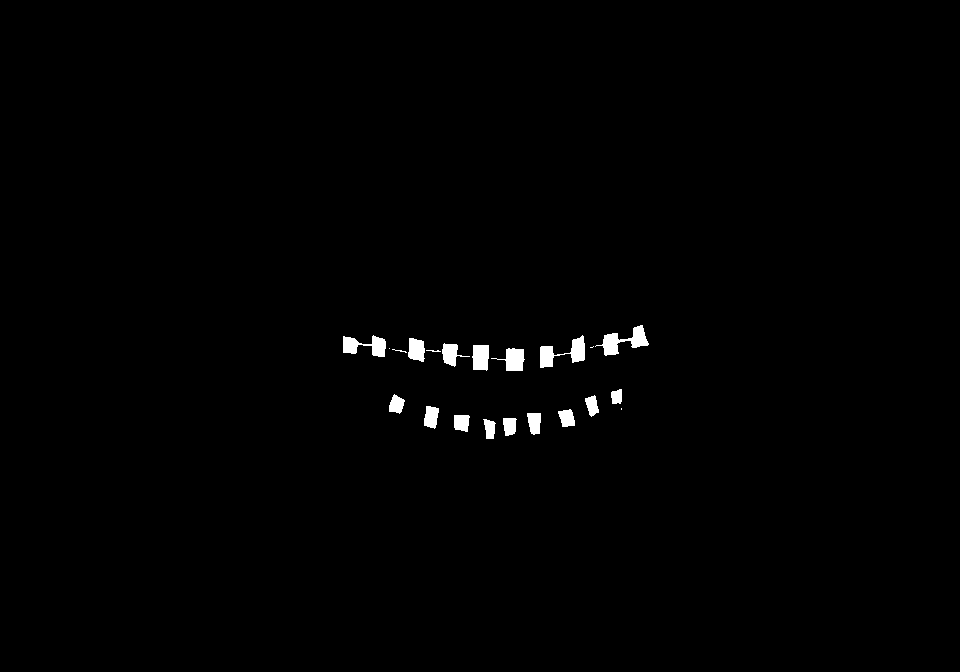

In [ ]:
i = 20
threshold = 0.5
img_pred = model.predict(x_train[i:i+1])[0,:,:,0]

img_pred[img_pred >= threshold] = 1
img_pred[img_pred < threshold] = 0

img = Image.fromarray(np.uint8(img_pred*255))
img

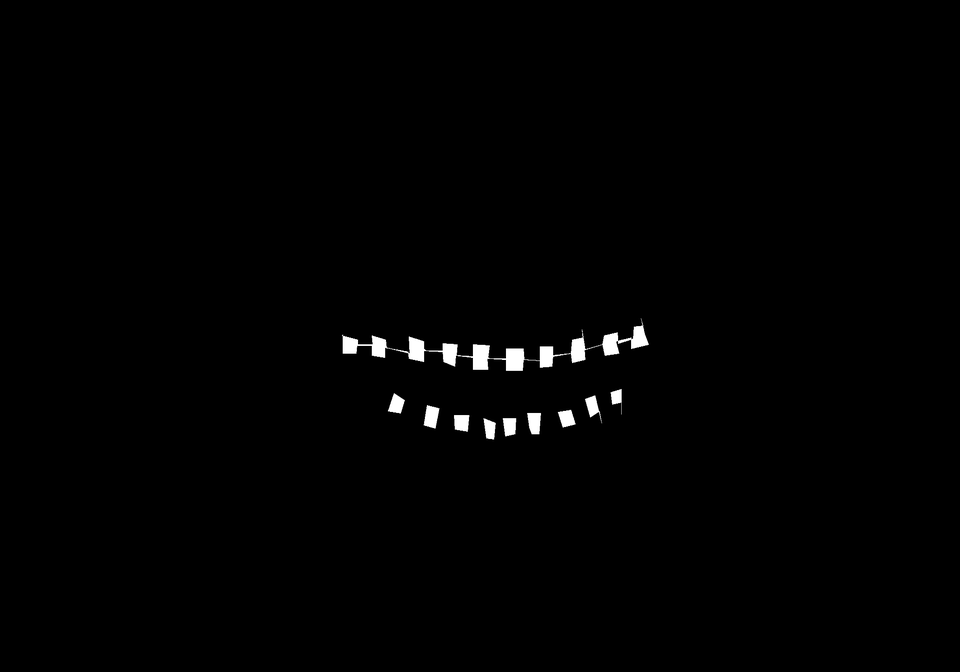

In [ ]:
Image.fromarray(np.uint8(y_train[i:i+1][0,:,:]*255))

(352, 640)

In [ ]:
model.evaluate(x_train,y_train)

9/9 [==============================] - 698s 77s/step - loss: 0.0056 - accuracy: 0.9933 - precision: 0.9534 - recall: 0.6002 - iou_value: 0.7050


[0.005627433303743601,
 0.9933362603187561,
 0.95344078540802,
 0.6002495884895325,
 0.705003023147583]

In [ ]:
model.evaluate(x_test,y_test)

6/6 [==============================] - 453s 74s/step - loss: 0.0053 - accuracy: 0.9934 - precision: 0.9605 - recall: 0.6023 - iou_value: 0.7180


[0.0052822488360106945,
 0.9934395551681519,
 0.9605361819267273,
 0.6022638082504272,
 0.718036413192749]

In [ ]:
model.summary()

Model: "U-Net_with_Attention_Gate"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_1 (InputLayer)        [(None, 672, 960, 3)]        0         []                            
                                                                                                  
 conv2d (Conv2D)             (None, 672, 960, 32)         896       ['input_1[0][0]']             
                                                                                                  
 conv2d_1 (Conv2D)           (None, 672, 960, 32)         9248      ['conv2d[0][0]']              
                                                                                                  
 max_pooling2d (MaxPooling2  (None, 336, 480, 32)         0         ['conv2d_1[0][0]']            
 D)                                                                       

In [ ]:
x_train.shape

(264, 672, 960, 3)

In [ ]:
x_test.shape

(172, 672, 960, 3)

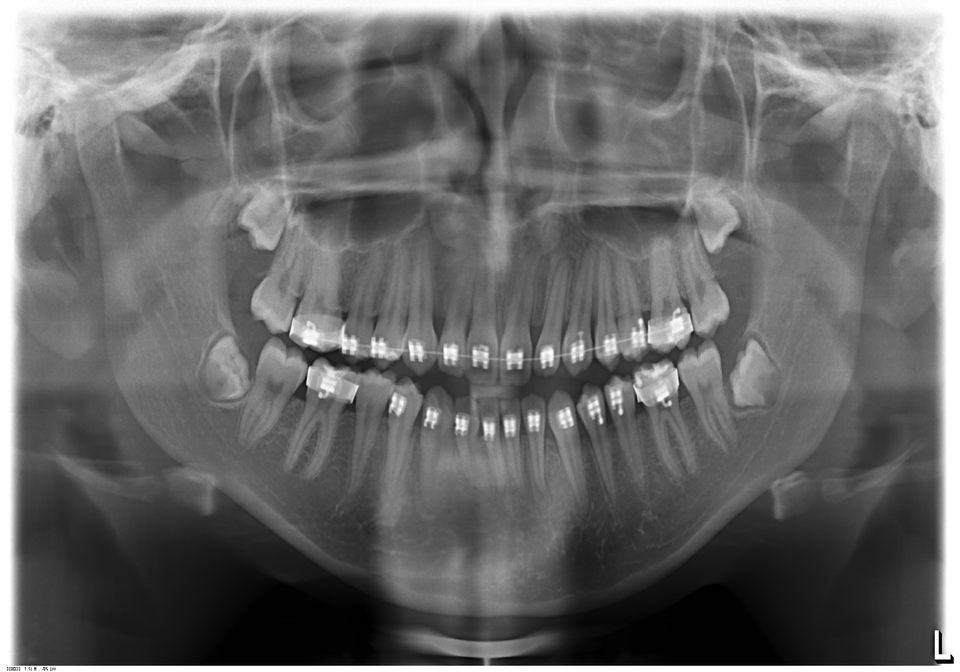

In [ ]:
Image.fromarray((x_train[i]*255).astype('uint8'))